# 第四问：期末储能价值缩放敏感性分析

本 Notebook 保留原文件名以便定位，实验已改为最终第四问模型的 **期末价值缩放分析**，不再把逐日求解称为七日联合优化。

主分析在第四问的问题二框架下进行：固定 PCA＋岭回归学得的凹二次价值函数，只改变无量纲系数 $\gamma$，考察高估或低估未来储能价值的影响。问题三包含额外的日内调整机制，本实验结论不直接外推到问题三。

固定惩罚方案始终采用已确定的 **λ＝0.45 元/kWh、目标6000 kWh**，作为单独的对照；不使用5.0替代选定值，也不把固定惩罚叠加到主模型上。旧实验的输出已从 Notebook 清除，新结果使用独立目录，不覆盖原图或提交表格。

## 1. 实验设计与信息口径

主模型当日目标为 $\min\{\sum_t\widehat p_{d,t}g_{d,t}-\gamma V_d(x)\}$，其中
$x=E_{d,\mathrm{end}}-1200$，$V_d(x)=a_dx-b_dx^2/2$。

- γ＝1：原主模型；γ＜1：低估未来储能价值；γ＞1：高估未来储能价值；γ＝0：移除价值项的消融对照。
- 仅对 $a_d,b_d$ 同比例缩放，不重训价值模型、不重新选择风险分位数，保持边际价值非负且递减。
- 当天采用原 Q2 的0.85分位净负荷；价格取前一周同日同时刻。未来六天预测仅由决策日前的历史信息构造，六天优化仅用于估值标签，不是七天实际联合执行。
- 沿用开发期已选配置：价格及净负荷各取5个 PCA 分量，岭回归 α＝10。价值模型仅用2025年9月1日前的标签拟合，然后冻结。
- 评价2025年9—12月，各方案统一从6000 kWh起步，期内实际储能跨日连续。该区间在此前项目中已被查看，称“参数冻结后的敏感性评价”，不称全新独立测试。
- 实际富余先充电、缺口先放电，不足部分按真实电价5倍紧急购电；现金费用只含计划与紧急购电，不加惩罚、不扣价值奖励。
- 本轮不根据最低费用的 γ 重新选参。若需改变γ，应回到开发期选择，再另行评价。

In [1]:
from pathlib import Path
import sys, json, hashlib, importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'submit/q4.py').exists() and (p / 'q4/terminal_value/core.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('请从项目根目录或 q4 目录启动 Notebook')
sys.dont_write_bytecode = True
CORE_PATH = ROOT / 'q4/terminal_value/core.py'
spec = importlib.util.spec_from_file_location('q4_sensitivity_core', CORE_PATH)
core = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = core
spec.loader.exec_module(core)
OUT = ROOT / 'q4/sensitivity_outputs/value_scale'
OUT.mkdir(parents=True, exist_ok=True)
GAMMAS = [0.0, 0.5, 0.75, 0.9, 1.0, 1.1, 1.25, 1.5]
START, END = '2025-09-01', '2025-12-31'
CONFIG = dict(kind='quadratic', feature='pca', components=5, alpha=10.0)
FIXED_LAMBDA = 0.45
assert 1.0 in GAMMAS and all(g >= 0 for g in GAMMAS)
plt.rcParams.update({'font.sans-serif': ['Microsoft YaHei', 'SimHei', 'DejaVu Sans'],
                     'axes.unicode_minus': False, 'figure.dpi': 120})
print('结果目录：', OUT)

结果目录： E:\桌面\CUMCM_2026\q4\sensitivity_outputs\value_scale


In [2]:
data = core.load_data()
labels = core.build_labels(data)
idx = np.flatnonzero((data['dates'] >= pd.Timestamp(START)) &
                    (data['dates'] <= pd.Timestamp(END))).tolist()
assert len(idx) == 122 and np.all(np.diff(idx) == 1)
train = [labels[d] for d in sorted(labels) if d < idx[0]]
eval_rows = [labels[d] for d in idx]
assert max(r['index'] for r in train) < min(idx)
for row in train + eval_rows:
    assert pd.Timestamp(row['information_cutoff']) < pd.Timestamp(row['date'])
    assert all(pd.Timestamp(ref) < pd.Timestamp(row['date']) for ref in row['references'])
model = core.ValueModel(**CONFIG).fit(train)
base_rewards = model.predict(eval_rows)
assert all(r.kind == 'quadratic' and r.b >= 0 and
           r.a-r.b*core.CAP >= -1e-9 for r in base_rewards)
# core.Reward('fixed') 的实际实现须与论文已选系数相符。
fixed_reward = core.Reward('fixed')
assert np.isclose(fixed_reward.value(0), -FIXED_LAMBDA * abs(core.EMIN-core.E0))
assert np.isclose(fixed_reward.value(core.CAP), -FIXED_LAMBDA * abs(core.EMAX-core.E0))
manifest = dict(period=[START, END], days=len(idx), config=CONFIG, gammas=GAMMAS,
                fixed_lambda=FIXED_LAMBDA, target_kwh=core.E0,
                risk_quantile=core.Q, initial_storage_kwh=core.E0,
                data_key=data['key'], core_sha256=hashlib.sha256(CORE_PATH.read_bytes()).hexdigest(),
                scope='Q4-2 frozen value-model sensitivity; no gamma reselection')
(OUT / 'manifest.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'训练标签 {len(train)} 条；冻结评价 {len(idx)} 天；不按 γ 重新训练或选参。')

价值标签：24/358 天


价值标签：54/358 天


价值标签：84/358 天


价值标签：114/358 天


价值标签：144/358 天


...

价值标签：264/358 天


价值标签：294/358 天


价值标签：324/358 天


价值标签：354/358 天


训练标签 236 条；冻结评价 122 天；不按 γ 重新训练或选参。


## 2. 主分析：γ 缩放与 λ＝0.45 对照

每个方案重新计算完整122天，使用同一组预测及同一实际执行规则。报告现金费用、紧急购电、最终库存和计划末电量与实际末电量的偏差，避免把期末少留电造成的费用下降直接解释为策略改善。

In [3]:
summaries, daily_tables = [], []
def evaluate_case(name, rewards, gamma=np.nan):
    daily, slots = core.backtest(data, idx, rewards, keep_slots=True)
    assert len(daily) == len(idx) and len(slots) == len(idx)*144
    assert np.isclose(daily.initial_storage.iloc[0], core.E0)
    assert np.allclose(slots.storage_start.to_numpy()[1:],
                       slots.storage_end.to_numpy()[:-1], atol=core.TOL)
    assert np.allclose(slots.planned_cost, slots.actual_price*slots.planned_grid_kwh)
    assert np.allclose(slots.emergency_cost, 5*slots.actual_price*slots.emergency_kwh)
    row = dict(strategy=name, gamma=gamma, **core.summary(daily))
    daily = daily.assign(strategy=name, gamma=gamma)
    daily.to_csv(OUT / f'daily_{name}.csv', index=False, encoding='utf-8-sig')
    summaries.append(row)
    daily_tables.append(daily)
    print(f'{name}: 现金费用 {row["cash_cost"]:,.2f} 元；最终储能 {row["end_storage"]:,.2f} kWh')

evaluate_case('fixed_lambda045', [core.Reward('fixed') for _ in idx])
for gamma in GAMMAS:
    rewards = [core.Reward('quadratic', gamma*r.a, gamma*r.b) for r in base_rewards]
    assert all(np.isclose(s.value(core.CAP/2), gamma*r.value(core.CAP/2))
               for s, r in zip(rewards, base_rewards))
    evaluate_case(f'gamma_{gamma:g}', rewards, gamma)

summary = pd.DataFrame(summaries)
base = summary.loc[summary.gamma.eq(1.0)].iloc[0]
fixed = summary.loc[summary.strategy.eq('fixed_lambda045')].iloc[0]
summary['delta_vs_gamma1_yuan'] = summary.cash_cost-base.cash_cost
summary['delta_vs_gamma1_percent'] = 100*summary.delta_vs_gamma1_yuan/base.cash_cost
summary['saving_vs_fixed_yuan'] = fixed.cash_cost-summary.cash_cost
summary.to_csv(OUT / '01_sensitivity_summary.csv', index=False, encoding='utf-8-sig')
daily_all = pd.concat(daily_tables, ignore_index=True)
display(summary[['strategy','cash_cost','delta_vs_gamma1_percent','saving_vs_fixed_yuan',
                 'emergency_kwh','end_storage','mean_abs_terminal_gap']].round(3))

fixed_lambda045: 现金费用 5,546,522.76 元；最终储能 5,923.52 kWh


gamma_0: 现金费用 5,554,377.95 元；最终储能 1,544.84 kWh


gamma_0.5: 现金费用 5,554,311.19 元；最终储能 1,544.84 kWh


gamma_0.75: 现金费用 5,547,085.75 元；最终储能 1,544.84 kWh


gamma_0.9: 现金费用 5,537,111.06 元；最终储能 5,923.52 kWh


gamma_1: 现金费用 5,537,658.03 元；最终储能 9,565.26 kWh


gamma_1.1: 现金费用 5,550,866.61 元；最终储能 10,800.00 kWh


gamma_1.25: 现金费用 5,574,231.86 元；最终储能 10,800.00 kWh


gamma_1.5: 现金费用 5,589,102.86 元；最终储能 10,800.00 kWh


,strategy,cash_cost,delta_vs_gamma1_percent,saving_vs_fixed_yuan,emergency_kwh,end_storage,mean_abs_terminal_gap
0,fixed_lambda045,5546522.758,0.160,0.000,17618.149,5923.523,789.704
1,gamma_0,5554377.950,0.302,-7855.193,17544.240,1544.844,879.077
2,gamma_0.5,5554311.190,0.301,-7788.432,17525.461,1544.844,879.106
3,gamma_0.75,5547085.746,0.170,-562.988,17525.461,1544.844,862.970
4,gamma_0.9,5537111.065,-0.010,9411.693,17567.854,5923.523,801.411
5,gamma_1,5537658.025,0.000,8864.733,17317.126,9565.256,713.842
6,gamma_1.1,5550866.613,0.239,-4343.855,17287.740,10800.000,508.283
7,gamma_1.25,5574231.859,0.660,-27709.101,17317.825,10800.000,183.104
8,gamma_1.5,5589102.861,0.929,-42580.103,17317.825,10800.000,82.531


## 3. 主图：费用、紧急购电与期末库存

γ＝1始终是参照点，不把扫描中费用最低的点改称“最终最优参数”。固定λ对照用水平虚线标示，与γ的横坐标无关。

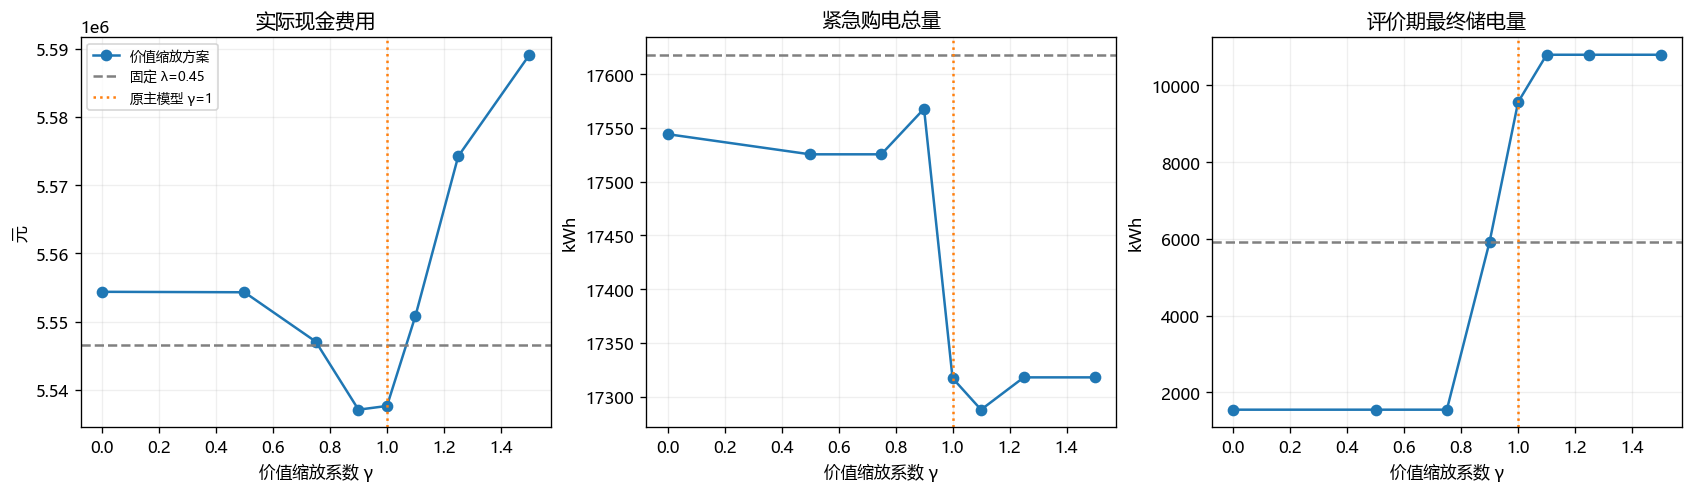

In [4]:
g = summary.loc[summary.gamma.notna()].sort_values('gamma')
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, field, title, unit in zip(axes,
        ['cash_cost', 'emergency_kwh', 'end_storage'],
        ['实际现金费用', '紧急购电总量', '评价期最终储电量'],
        ['元', 'kWh', 'kWh']):
    ax.plot(g.gamma, g[field], marker='o', label='价值缩放方案')
    ax.axhline(fixed[field], color='gray', linestyle='--', label='固定 λ=0.45')
    ax.axvline(1, color='tab:orange', linestyle=':', label='原主模型 γ=1')
    ax.set(xlabel='价值缩放系数 γ', ylabel=unit, title=title)
    ax.grid(alpha=.2)
axes[0].legend(fontsize=8)
fig.savefig(OUT / '02_gamma_cost_risk_inventory.png', dpi=300)
fig.savefig(OUT / '02_gamma_cost_risk_inventory.pdf')
plt.show()

## 4. 库存估值与跨月一致性

补充统一库存估值 $C_v=C-v(E_{\mathrm{final}}-E_{\mathrm{initial}})$，取 $v\in\{0,0.45,0.9\}$ 元/kWh。这里的v是会计评价口径，不是终端惩罚系数，也不代表允许售电。

各月费用从同一次连续回测拆分，不在月初重置储能。月度差额只用于描述结果随月份的变化，不单凭每月费用判断库存转移后的优劣。

In [5]:
inventory = summary[['strategy','gamma','cash_cost','inventory_adjusted_045','inventory_adjusted_090']].copy()
inventory.to_csv(OUT / '03_inventory_valuation.csv', index=False, encoding='utf-8-sig')
display(inventory.round(2))
daily_all['month'] = pd.to_datetime(daily_all.date).dt.to_period('M').astype(str)
monthly = daily_all.groupby(['strategy','month'], as_index=False).agg(
    cash_cost=('total_cost','sum'), emergency_kwh=('emergency_kwh','sum'),
    initial_storage=('initial_storage','first'), end_storage=('end_storage','last'))
baseline_monthly = monthly.loc[monthly.strategy.eq('gamma_1'), ['month','cash_cost']].rename(
    columns={'cash_cost':'baseline_cost'})
monthly = monthly.merge(baseline_monthly, on='month', validate='many_to_one')
monthly['delta_vs_gamma1_yuan'] = monthly.cash_cost-monthly.baseline_cost
monthly.to_csv(OUT / '04_monthly_comparison.csv', index=False, encoding='utf-8-sig')
display(monthly.pivot(index='strategy', columns='month', values='delta_vs_gamma1_yuan').round(2))

,strategy,gamma,cash_cost,inventory_adjusted_045,inventory_adjusted_090
0,fixed_lambda045,NaN,5546522.76,5546557.17,5546591.59
1,gamma_0,0.00,5554377.95,5556382.77,5558387.59
2,gamma_0.5,0.50,5554311.19,5556316.01,5558320.83
3,gamma_0.75,0.75,5547085.75,5549090.57,5551095.39
4,gamma_0.9,0.90,5537111.06,5537145.48,5537179.89
5,gamma_1,1.00,5537658.03,5536053.66,5534449.29
6,gamma_1.1,1.10,5550866.61,5548706.61,5546546.61
7,gamma_1.25,1.25,5574231.86,5572071.86,5569911.86
8,gamma_1.5,1.50,5589102.86,5586942.86,5584782.86


month,2025-09,2025-10,2025-11,2025-12
strategy,,,,
fixed_lambda045,-315.83,4202.76,2440.93,2536.87
gamma_0,-651.09,5546.63,4382.77,7441.62
gamma_0.5,-650.94,5539.74,4317.00,7447.36
gamma_0.75,-1231.39,3713.98,2165.52,4779.61
gamma_0.9,-1996.05,1123.73,-211.46,536.82
gamma_1,0.00,0.00,0.00,0.00
gamma_1.1,5910.16,1964.11,3240.17,2094.15
gamma_1.25,15028.56,9797.11,7048.58,4699.58
gamma_1.5,22064.40,13033.96,9811.39,6535.09


## 5. 结果解读与论文使用边界

首先观察γ＝1附近（0.9、1.1）的扰动，再考察较大偏差与γ＝0消融。费用相近而库存或紧急购电变化明显，不能笼统写成“所有指标均稳健”；曲线平坦也是有效结果，不为强化图形差异更换λ。

本实验使用小时粒度的六天估值标签，实际执行为10分钟粒度；学习奖励作用于计划末电量，实际末电量可能偏离。以下自动生成局部变化范围，是否具有经济意义需结合紧急购电和库存表解释，不预设结论。

原“七日末目标”实验未保留为主分析，因为它逐日独立规划且仅第七日施加惩罚，与当前期末价值模型不同。若另做终端目标敏感性实验，应固定λ＝0.45并明确其为固定惩罚方案的对照，不与γ结果混为一谈。

In [6]:
local = summary.loc[summary.gamma.isin([0.9, 1.0, 1.1])]
max_change = local.delta_vs_gamma1_percent.abs().max()
report = (
    f'评价期：{START} 至 {END}，共{len(idx)}天（Q4-2框架）。\n'
    f'原主模型γ=1实际现金费用：{base.cash_cost:,.2f}元。\n'
    f'固定λ=0.45对照实际现金费用：{fixed.cash_cost:,.2f}元。\n'
    f'γ在0.9、1.0、1.1之间变化时，相对γ=1的现金费用最大绝对变化为{max_change:.4f}%。\n'
    '同时报告紧急购电、最终库存及统一库存估值结果；不按本次评价重选γ。\n'
    '这是参数冻结后的敏感性评价，不作为未曾查看数据的独立测试证明。\n'
)
(OUT / '05_interpretation.txt').write_text(report, encoding='utf-8')
print(report)

评价期：2025-09-01 至 2025-12-31，共122天（Q4-2框架）。
原主模型γ=1实际现金费用：5,537,658.03元。
固定λ=0.45对照实际现金费用：5,546,522.76元。
γ在0.9、1.0、1.1之间变化时，相对γ=1的现金费用最大绝对变化为0.2385%。
同时报告紧急购电、最终库存及统一库存估值结果；不按本次评价重选γ。
这是参数冻结后的敏感性评价，不作为未曾查看数据的独立测试证明。

